In [1]:
import pandas as pd
import numpy as np

In [2]:
data_path = "../data/raw/confounding_real_exercise-health/ESS11e04_2.csv"

df = pd.read_csv(data_path)

df.head()

C:\Users\andre\AppData\Local\Temp\ipykernel_28140\3585966632.py:3: DtypeWarning: Columns (198,204,681) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,rinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
0,ESS11e04_2,11,4.2,02.07.2026,50014,AT,1.185115,0.392891,0.330915,0.130013,...,NaN,2023-11-12 15:26:55,2023-11-12 15:21:28,2023-11-12 15:26:55,30.0,1,2.0,0.000579,107,317
1,ESS11e04_2,11,4.2,02.07.2026,50030,AT,0.609898,0.325153,0.330915,0.107598,...,NaN,2023-10-18 10:44:18,2023-10-18 10:42:22,2023-10-18 10:44:18,40.0,1,1.0,0.001124,69,128
2,ESS11e04_2,11,4.2,02.07.2026,50057,AT,1.392330,4.000023,0.330915,1.323666,...,NaN,2023-09-30 14:13:33,2023-09-30 14:08:31,2023-09-30 14:13:33,42.0,1,2.0,0.000493,18,418
3,ESS11e04_2,11,4.2,02.07.2026,50106,AT,0.556062,0.176228,0.330915,0.058316,...,NaN,2023-06-30 15:11:21,2023-06-30 15:08:05,2023-06-30 15:11:21,34.0,1,1.0,0.001233,101,295
4,ESS11e04_2,11,4.2,02.07.2026,50145,AT,0.722795,1.060940,0.330915,0.351080,...,NaN,2023-07-11 11:14:03,2023-07-11 11:10:02,2023-07-11 11:14:03,57.0,1,2.0,0.000949,115,344


In [3]:
# variables needed for the DAG
columns = [
    "cntry",
    "dosprt",
    "health",
    "agea",
    "gndr",
    "edlveat",
]

In [4]:
# Austria only
df_austria = df.loc[df["cntry"] == "AT", columns].copy()

print("Shape:", df_austria.shape)
df_austria.head()

Shape: (2354, 6)


,cntry,dosprt,health,agea,gndr,edlveat
0,AT,3,3,65,1,6.0
1,AT,5,2,21,2,10.0
2,AT,3,1,53,2,12.0
3,AT,3,3,78,2,9.0
4,AT,3,2,64,1,6.0


In [5]:
# basic checks
print(df_austria.dtypes)
print()
print(df_austria.isna().sum())
print()
print(df_austria.nunique())

cntry       object
dosprt       int64
health       int64
agea         int64
gndr         int64
edlveat    float64
dtype: object

cntry      0
dosprt     0
health     0
agea       0
gndr       0
edlveat    0
dtype: int64

cntry       1
dosprt     10
health      5
agea       76
gndr        2
edlveat    20
dtype: int64


In [6]:
# inspect values and frequencies
for col in ["dosprt", "health", "agea", "gndr", "edlveat"]:
    print(f"\n{col}:")
    print(df_austria[col].value_counts().sort_index())


dosprt:
dosprt
0     375
1     186
2     342
3     352
4     234
5     273
6     121
7     453
77      5
88     13
Name: count, dtype: int64

health:
health
1     660
2    1030
3     531
4     120
5      13
Name: count, dtype: int64

agea:
agea
15    11
16    10
17     8
18    12
19    19
      ..
86    20
87     9
88     7
89     8
90    27
Name: count, Length: 76, dtype: int64

gndr:
gndr
1     993
2    1361
Name: count, dtype: int64

edlveat:
edlveat
1.0         2
2.0        16
3.0       153
4.0       154
5.0        28
6.0       905
7.0       284
8.0       131
9.0        63
10.0      205
11.0       38
12.0       85
13.0       35
14.0       48
15.0       36
16.0      108
17.0       11
18.0       30
5555.0     21
7777.0      1
Name: count, dtype: int64


In [7]:
# remove missing-response codes
df_clean = df_austria[
    ~df_austria["dosprt"].isin([77, 88, 99])
    & ~df_austria["edlveat"].isin([7777, 8888, 9999])
].copy()

print("Before cleaning:", len(df_austria))
print("After cleaning:", len(df_clean))

Before cleaning: 2354
After cleaning: 2335


In [8]:
# reverse health so higher values mean better health
df_clean["health_score"] = 6 - df_clean["health"]

df_clean[["health", "health_score"]].head()

,health,health_score
0,3,3
1,2,4
2,1,5
3,3,3
4,2,4


In [9]:
# final cleaning checks
print(df_clean.shape)
print()
print(df_clean[["dosprt", "health_score", "agea", "gndr", "edlveat"]].describe().round(2))
print()
print(df_clean.isna().sum())

(2335, 7)

        dosprt  health_score     agea     gndr  edlveat
count  2335.00       2335.00  2335.00  2335.00  2335.00
mean      3.48          3.94    55.70     1.58    55.18
std       2.41          0.87    18.33     0.49   511.32
min       0.00          1.00    15.00     1.00     1.00
25%       2.00          3.00    42.00     1.00     6.00
50%       3.00          4.00    57.00     2.00     6.00
75%       5.00          5.00    70.00     2.00    10.00
max       7.00          5.00    90.00     2.00  5555.00

cntry           0
dosprt          0
health          0
agea            0
gndr            0
edlveat         0
health_score    0
dtype: int64


In [10]:
# prepare categorical confounders
df_clean["female"] = (df_clean["gndr"] == 2).astype(int)

df_clean["edlveat"] = df_clean["edlveat"].astype("category")

In [11]:
# inspect exposure and outcome distributions
print("Physical activity:")
print(df_clean["dosprt"].value_counts().sort_index())

print("\nHealth score:")
print(df_clean["health_score"].value_counts().sort_index())

Physical activity:
dosprt
0    375
1    186
2    342
3    351
4    234
5    273
6    121
7    453
Name: count, dtype: int64

Health score:
health_score
1      13
2     118
3     522
4    1026
5     656
Name: count, dtype: int64


In [12]:
# naive association between physical activity and health
naive_coef, naive_cov = np.polyfit(
    df_clean["dosprt"],
    df_clean["health_score"],
    1,
    cov=True
)

naive_slope = naive_coef[0]
naive_se = np.sqrt(naive_cov[0, 0])

naive_ci_lower = naive_slope - 1.96 * naive_se
naive_ci_upper = naive_slope + 1.96 * naive_se

correlation = df_clean["dosprt"].corr(df_clean["health_score"])

print(f"Correlation: {correlation:.3f}")
print(f"Naive slope: {naive_slope:.3f}")
print(f"95% CI: [{naive_ci_lower:.3f}, {naive_ci_upper:.3f}]")

Correlation: 0.280
Naive slope: 0.101
95% CI: [0.087, 0.115]


In [13]:
# dummy-code education
df_causal = pd.get_dummies(
    df_clean,
    columns=["edlveat"],
    drop_first=True,
    dtype=int
)

df_causal.head()

,cntry,dosprt,health,agea,gndr,health_score,female,edlveat_2.0,edlveat_3.0,edlveat_4.0,...,edlveat_10.0,edlveat_11.0,edlveat_12.0,edlveat_13.0,edlveat_14.0,edlveat_15.0,edlveat_16.0,edlveat_17.0,edlveat_18.0,edlveat_5555.0
0,AT,3,3,65,1,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AT,5,2,21,2,4,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,AT,3,1,53,2,5,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,AT,3,3,78,2,3,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AT,3,2,64,1,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
from dowhy import CausalModel

education_vars = [
    col for col in df_causal.columns
    if col.startswith("edlveat_")
]

graph = """
digraph {
    agea -> dosprt;
    agea -> health_score;

    female -> dosprt;
    female -> health_score;

    dosprt -> health_score;
"""

for var in education_vars:
    graph += f"""
    {var} -> dosprt;
    {var} -> health_score;
    """

graph += "}"

c:\python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
model = CausalModel(
    data=df_causal,
    treatment="dosprt",
    outcome="health_score",
    graph=graph
)

identified_estimand = model.identify_effect()

print(identified_estimand.get_backdoor_variables())

['edlveat_14.0', 'edlveat_9.0', 'edlveat_18.0', 'female', 'edlveat_8.0', 'edlveat_3.0', 'agea', 'edlveat_12.0', 'edlveat_4.0', 'edlveat_6.0', 'edlveat_17.0', 'edlveat_5555.0', 'edlveat_5.0', 'edlveat_15.0', 'edlveat_10.0', 'edlveat_16.0', 'edlveat_13.0', 'edlveat_2.0', 'edlveat_11.0', 'edlveat_7.0']


In [23]:
# estimate adjusted effect of one additional active day
causal_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    confidence_intervals=True
)

causal_ci = causal_estimate.get_confidence_intervals(confidence_level=0.95)

causal_ci_lower = causal_ci[0][0]
causal_ci_upper = causal_ci[0][1]

print(f"Adjusted causal estimate: {causal_estimate.value:.3f}")
print(f"95% CI: [{causal_ci_lower:.3f}, {causal_ci_upper:.3f}]")

Adjusted causal estimate: 0.072
95% CI: [0.059, 0.085]


In [17]:
# add an irrelevant random variable
refute_random = model.refute_estimate(
    identified_estimand,
    causal_estimate,
    method_name="random_common_cause"
)

print(refute_random)

Refute: Add a random common cause
Estimated effect:0.07239868917657732
New effect:0.07237510435269465
p value:0.74



In [18]:
# replace physical activity with a random placebo
refute_placebo = model.refute_estimate(
    identified_estimand,
    causal_estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)

print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:0.07239868917657732
New effect:0.0013240456463019079
p value:0.8400000000000001



In [19]:
# repeat estimation on a subset of the data
refute_subset = model.refute_estimate(
    identified_estimand,
    causal_estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8
)

print(refute_subset)

c:\python313\Lib\site-packages\dowhy\causal_estimators\linear_regression_estimator.py:105: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(data[self._target_estimand.outcome_variable[0]], features).fit()


Refute: Use a subset of data
Estimated effect:0.07239868917657732
New effect:0.07243239688321246
p value:0.98



In [26]:
# summarize main results
results = pd.DataFrame({
    "Method": [
        "Naive association",
        "Adjusted causal estimate"
    ],
    "Effect": [
        naive_slope,
        causal_estimate.value
    ],
    "95% CI": [
        f"[{naive_ci_lower:.3f}, {naive_ci_upper:.3f}]",
        f"[{causal_ci_lower:.3f}, {causal_ci_upper:.3f}]"
    ]
})

results["Effect"] = results["Effect"].round(3)

results

,Method,Effect,95% CI
0,Naive association,0.101,"[0.087, 0.115]"
1,Adjusted causal estimate,0.072,"[0.059, 0.085]"


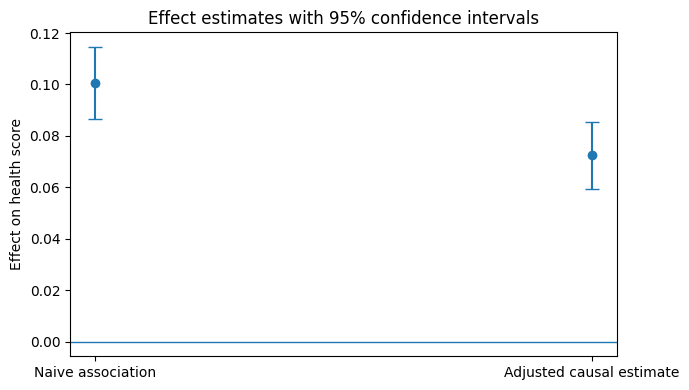

In [29]:
import matplotlib.pyplot as plt

# values for plotting
methods = ["Naive association", "Adjusted causal estimate"]
effects = [naive_slope, causal_estimate.value]

ci_lowers = [naive_ci_lower, causal_ci_lower]
ci_uppers = [naive_ci_upper, causal_ci_upper]

# convert CI bounds to distances from point estimate
yerr_lower = [effect - low for effect, low in zip(effects, ci_lowers)]
yerr_upper = [up - effect for effect, up in zip(effects, ci_uppers)]

plt.figure(figsize=(7, 4))

plt.errorbar(
    methods,
    effects,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    capsize=5
)

plt.axhline(0, linewidth=1)
plt.ylabel("Effect on health score")
plt.title("Effect estimates with 95% confidence intervals")

plt.tight_layout()
plt.show()

### Interpretation

The naive associational analysis indicates that each additional physically active day per week is associated with an increase of approximately 0.101 points in the reversed 1–5 subjective health score.

After adjusting for age, gender, and education according to the assumed causal model, the estimated effect decreases to approximately 0.072 points per additional active day. The direction therefore remains positive, but part of the observed association appears to be explained by the included confounders. Both 95% confidence intervals remain entirely above zero, indicating a positive estimated relationship in both the naive and adjusted analyses.

Unlike the synthetic case studies, the true causal effect is unknown. The adjusted estimate should therefore be interpreted as a causal effect only under the assumptions represented by the DAG and the assumption that relevant confounding has been sufficiently controlled.

### Limitation

Subjective health is measured on an ordinal five-category scale. In this prototype, the reversed health score is treated approximately as continuous so that a simple linear regression can be used for a transparent comparison. This simplifies interpretation, but assumes approximately equal distances between adjacent health categories.

In [22]:
# compare progressively adjusted models
X_age = np.column_stack([
    np.ones(len(df_clean)),
    df_clean["dosprt"],
    df_clean["agea"]
])

X_age_gender = np.column_stack([
    np.ones(len(df_clean)),
    df_clean["dosprt"],
    df_clean["agea"],
    df_clean["female"]
])

education_cols = [
    col for col in df_causal.columns
    if col.startswith("edlveat_")
]

X_full = np.column_stack([
    np.ones(len(df_causal)),
    df_causal["dosprt"],
    df_causal["agea"],
    df_causal["female"],
    df_causal[education_cols].to_numpy()
])

y = df_clean["health_score"].to_numpy()

effect_age = np.linalg.lstsq(X_age, y, rcond=None)[0][1]
effect_age_gender = np.linalg.lstsq(X_age_gender, y, rcond=None)[0][1]
effect_full = np.linalg.lstsq(X_full, y, rcond=None)[0][1]

pd.DataFrame({
    "Adjustment": [
        "None",
        "Age",
        "Age + gender",
        "Age + gender + education"
    ],
    "Effect": [
        naive_slope,
        effect_age,
        effect_age_gender,
        effect_full
    ]
}).round(3)

,Adjustment,Effect
0,None,0.101
1,Age,0.080
2,Age + gender,0.080
3,Age + gender + education,0.072


### Adjustment-Set Sensitivity

The estimated relationship was also compared across progressively adjusted model specifications. The unadjusted estimate was 0.101. After adjusting for age, it decreased to approximately 0.080, while additionally including gender produced almost no further change. Including education in the full adjustment set reduced the estimate further to approximately 0.072.

This indicates that the estimated effect is moderately sensitive to the selected adjustment set, with age accounting for most of the reduction observed in these specifications. The analysis does not establish that any particular adjustment set represents the true causal structure, but it illustrates how the estimated effect depends on the causal assumptions used to determine which variables are controlled for.